# Imports

In [39]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from tqdm import tqdm
from utils_EDA import (outlier_count_IQR, outlier_filter_IQR,
                            bar_charts_categorical, distribution_plot_grid,
                            cor_heatmap, chi2_TestIndependence)
pd.options.display.float_format = '{:.2f}'.format

In [40]:
%cd ..
data = pd.read_csv('Datasets/donors_train.csv')
data.head()
%cd EDA

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\EDA


# General Data Exploration

In [41]:
data['CONTROL_NUMBER'].nunique()

13560

In [42]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13560 entries, 0 to 13559
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CONTROL_NUMBER               13560 non-null  int64  
 1   CARD_PROM_12                 13297 non-null  float64
 2   CHILDREN                     13298 non-null  float64
 3   DONOR_AGE                    10006 non-null  float64
 4   DONOR_GENDER                 13288 non-null  str    
 5   FILE_CARD_GIFT               13300 non-null  float64
 6   FREQUENCY_STATUS_97NK        13278 non-null  float64
 7   HOME_OWNER                   13274 non-null  str    
 8   INCOME_GROUP                 10271 non-null  float64
 9   LAST_GIFT_AMT                13299 non-null  float64
 10  LIFETIME_CARD_PROM           13300 non-null  float64
 11  LIFETIME_GIFT_AMOUNT         13287 non-null  float64
 12  LIFETIME_GIFT_COUNT          13285 non-null  float64
 13  LIFETIME_MAX_GIFT_AMT      

In [43]:
data.describe(include=['object'])

C:\Users\dinis\AppData\Local\Temp\ipykernel_8\1736911641.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,DONOR_GENDER,HOME_OWNER,RECENCY_STATUS_96NK,SES,URBANICITY
count,13288,13274,13298,13287,13291
unique,3,2,6,5,6
top,F,H,A,2,S
freq,7230,7233,8188,6380,3117


In [44]:
for val in data.select_dtypes('str').columns:
    print(f"Variable {val}: {data[val].value_counts(dropna=False)}")

Variable DONOR_GENDER: DONOR_GENDER
F      7230
M      5356
U       702
NaN     272
Name: count, dtype: int64
Variable HOME_OWNER: HOME_OWNER
H      7233
U      6041
NaN     286
Name: count, dtype: int64
Variable RECENCY_STATUS_96NK: RECENCY_STATUS_96NK
A      8188
S      2887
F      1051
N       830
E       284
NaN     262
L        58
Name: count, dtype: int64
Variable SES: SES
2      6380
1      4082
3      2274
?       297
NaN     273
4       254
Name: count, dtype: int64
Variable URBANICITY: URBANICITY
S      3117
R      2739
C      2737
T      2728
U      1674
?       296
NaN     269
Name: count, dtype: int64


In [45]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CONTROL_NUMBER,13560.00,96433.01,55926.03,5.00,47975.25,97023.00,145252.75,191775.00
CARD_PROM_12,13297.00,5.38,1.32,1.00,5.00,6.00,6.00,17.00
CHILDREN,13298.00,2.00,1.47,-2.30,1.00,2.00,3.00,6.22
DONOR_AGE,10006.00,58.81,17.57,0.00,46.00,60.00,73.00,108.95
FILE_CARD_GIFT,13300.00,5.24,4.83,-10.10,2.00,4.00,8.00,32.00
FREQUENCY_STATUS_97NK,13278.00,1.99,1.15,-1.36,1.00,2.00,3.00,5.28
INCOME_GROUP,10271.00,3.92,1.96,-1.74,2.00,4.00,5.00,9.50
LAST_GIFT_AMT,13299.00,16.64,12.95,-21.83,10.00,15.00,20.00,450.00
LIFETIME_CARD_PROM,13300.00,18.65,8.94,-7.21,11.00,18.00,26.00,55.00
LIFETIME_GIFT_AMOUNT,13287.00,104.88,112.12,-243.26,41.00,80.00,133.00,3775.00


In [46]:
data[(data['DONOR_AGE'] % 1 != 0) & (~data['DONOR_AGE'].isna())]

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
117,3319,7.00,0.00,8.66,F,5.00,2.00,U,5.00,10.00,...,19.00,0.00,0.00,2.00,0.10,0.00,1,S,7.00,0
160,62629,6.00,0.00,8.66,M,6.00,NaN,U,5.00,10.00,...,9.75,2.00,0.20,4.00,0.21,0.00,2,T,3.00,0
162,13133,6.00,2.00,108.95,F,8.00,2.00,H,4.00,26.00,...,23.50,2.00,0.22,2.00,0.10,1.00,1,S,3.00,0
215,147614,6.00,3.00,108.95,U,2.00,2.00,U,NaN,20.00,...,15.33,2.00,0.29,3.00,0.23,0.00,4,U,NaN,0
238,183924,4.00,0.00,108.95,M,1.00,1.00,H,4.00,15.00,...,15.00,0.00,0.00,1.00,0.06,0.00,2,C,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13054,87397,6.00,4.00,108.95,F,9.00,1.00,H,4.00,11.00,...,12.75,3.00,0.30,4.00,0.19,1.00,2,R,9.00,0
13140,99273,NaN,0.00,8.66,M,1.00,2.00,H,7.00,20.00,...,13.33,1.00,0.09,3.00,0.14,0.00,1,NaN,NaN,0
13155,138110,6.00,NaN,8.66,F,13.00,3.00,U,2.00,14.00,...,12.40,2.00,0.20,5.00,0.24,1.00,1,C,7.00,0
13187,132832,4.00,0.00,108.95,F,9.00,1.00,U,2.00,16.00,...,16.00,0.00,0.00,1.00,0.07,0.00,2,T,0.00,0


In [47]:
data[data['CHILDREN'] < 0]['CHILDREN'].value_counts()

CHILDREN
-2.30    67
Name: count, dtype: int64

In [48]:
data[data['FILE_CARD_GIFT'] < 0]['FILE_CARD_GIFT'].value_counts()

FILE_CARD_GIFT
-10.10    75
Name: count, dtype: int64

In [49]:
data[data['FREQUENCY_STATUS_97NK'] < 0]['FREQUENCY_STATUS_97NK'].value_counts()

FREQUENCY_STATUS_97NK
-1.36    66
Name: count, dtype: int64

In [50]:
data[data['INCOME_GROUP'] < 0]['INCOME_GROUP'].value_counts()

INCOME_GROUP
-1.74    68
Name: count, dtype: int64

In [51]:
data[data['INCOME_GROUP'] > 7]['INCOME_GROUP'].value_counts()

INCOME_GROUP
9.50    68
Name: count, dtype: int64

In [52]:
data[data['LAST_GIFT_AMT'] < 0]['LAST_GIFT_AMT'].value_counts()

LAST_GIFT_AMT
-21.83    67
Name: count, dtype: int64

Alguns problemas (FALTAM OUTROS, VER TUDO):
+ All variables have missing values
+ DONOR_GENDER has NaN and U category
+ HOME_OWNER has missing values
+ RECENCY_STATUS_96NK has missing values
+ URBANICITY and SES have a "?" value
+ SES mentions 5 profiles in description but appears to only have 4 options in the data.
+ CHILDREN contains negative and non-integer values. All negative values are the same (-2.29...)
+ DONOR_AGE has a minimum value of 0, values for underage people and non-integer values.
+ FILE_CARD_GIFT has negative values, which are all the same (-16.09857)
+ FREQUENCY_STATUS_97NK has negative values, which are all the same (-1.363824) and non-integer values.
+ INCOME_GROUP has negative values (-1.737977), non-integer values and values greater than 7 (9.563281)
+ LAST_GIFT_AMT has negative values (-21.8336)

In [53]:
cat_cols = list(data.select_dtypes(include='str').columns) + ['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING']
cat_cols

['DONOR_GENDER',
 'HOME_OWNER',
 'RECENCY_STATUS_96NK',
 'SES',
 'URBANICITY',
 'INCOME_GROUP',
 'RECENT_STAR_STATUS',
 'WEALTH_RATING']

<Axes: xlabel='TARGET_B', ylabel='count'>

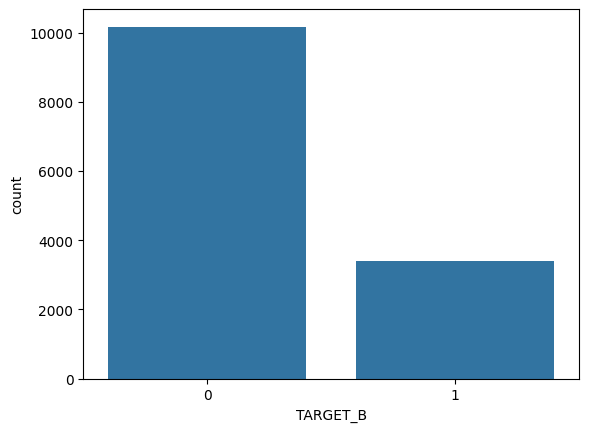

In [54]:
sns.countplot(data=data, x='TARGET_B')

# Missing Values

In [55]:
pd.merge(data.isna().sum().to_frame('N Missing'), data.isna().sum().to_frame('% Missing') / len(data) * 100, left_index=True, right_index=True)

,N Missing,% Missing
CONTROL_NUMBER,0,0.00
CARD_PROM_12,263,1.94
CHILDREN,262,1.93
DONOR_AGE,3554,26.21
DONOR_GENDER,272,2.01
FILE_CARD_GIFT,260,1.92
FREQUENCY_STATUS_97NK,282,2.08
HOME_OWNER,286,2.11
INCOME_GROUP,3289,24.26
LAST_GIFT_AMT,261,1.92


In [56]:
data.isna().sum(axis=1).value_counts()

1    4324
2    3592
0    2345
3    2136
4     840
5     265
6      52
7       5
8       1
Name: count, dtype: int64

In [57]:
var_value_counts = data[data['URBANICITY'].isna()]['TARGET_B'].value_counts(normalize=True)
print(var_value_counts[0] > 0.8)

False


In [58]:
for var in data.columns[1:-1]:
    var_value_counts = data[data[var].isna()]['TARGET_B'].value_counts(normalize=True)
    if var_value_counts[0] < 0.8:
        print(var)
        print(var_value_counts)

CARD_PROM_12
TARGET_B
0   0.75
1   0.25
Name: proportion, dtype: float64
CHILDREN
TARGET_B
0   0.74
1   0.26
Name: proportion, dtype: float64
DONOR_AGE
TARGET_B
0   0.76
1   0.24
Name: proportion, dtype: float64
DONOR_GENDER
TARGET_B
0   0.75
1   0.25
Name: proportion, dtype: float64
FILE_CARD_GIFT
TARGET_B
0   0.73
1   0.27
Name: proportion, dtype: float64
FREQUENCY_STATUS_97NK
TARGET_B
0   0.78
1   0.22
Name: proportion, dtype: float64
HOME_OWNER
TARGET_B
0   0.73
1   0.27
Name: proportion, dtype: float64
INCOME_GROUP
TARGET_B
0   0.75
1   0.25
Name: proportion, dtype: float64
LAST_GIFT_AMT
TARGET_B
0   0.76
1   0.24
Name: proportion, dtype: float64
LIFETIME_CARD_PROM
TARGET_B
0   0.75
1   0.25
Name: proportion, dtype: float64
LIFETIME_GIFT_AMOUNT
TARGET_B
0   0.75
1   0.25
Name: proportion, dtype: float64
LIFETIME_GIFT_COUNT
TARGET_B
0   0.76
1   0.24
Name: proportion, dtype: float64
LIFETIME_MAX_GIFT_AMT
TARGET_B
0   0.74
1   0.26
Name: proportion, dtype: float64
LIFETIME_MIN_GIFT_

# Outliers

In [59]:
data[['CONTROL_NUMBER', 'INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING']]

,CONTROL_NUMBER,INCOME_GROUP,RECENT_STAR_STATUS,WEALTH_RATING
0,61745,5.00,0.00,NaN
1,112703,NaN,0.00,NaN
2,166437,4.00,1.00,NaN
3,170621,6.00,0.00,NaN
4,44428,3.00,0.00,NaN
...,...,...,...,...
13555,34797,6.00,6.00,3.00
13556,7550,2.00,1.00,3.00
13557,115215,1.00,0.00,NaN
13558,88067,NaN,0.00,NaN


In [60]:
num_cols = data.select_dtypes(include=np.number).columns.drop([
    'CONTROL_NUMBER', 'INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING', 'TARGET_B'])

In [61]:
outlier_count_IQR(data, num_cols)

,N Outliers
CARD_PROM_12,1261
CHILDREN,133
DONOR_AGE,6
FILE_CARD_GIFT,437
FREQUENCY_STATUS_97NK,0
LAST_GIFT_AMT,553
LIFETIME_CARD_PROM,6
LIFETIME_GIFT_AMOUNT,803
LIFETIME_GIFT_COUNT,588
LIFETIME_MAX_GIFT_AMT,874


In [62]:
outlier_count_IQR(data, num_cols, outlier_type='extreme')

,N Outliers
CARD_PROM_12,265
CHILDREN,0
DONOR_AGE,0
FILE_CARD_GIFT,12
FREQUENCY_STATUS_97NK,0
LAST_GIFT_AMT,234
LIFETIME_CARD_PROM,0
LIFETIME_GIFT_AMOUNT,377
LIFETIME_GIFT_COUNT,89
LIFETIME_MAX_GIFT_AMT,561


In [63]:
outlier_filter_IQR(data, num_cols)

Excluding all normal outliers, we are left with 12.57% of our dataset


In [64]:
outlier_filter_IQR(data, num_cols, outlier_type='extreme')

Excluding all extreme outliers, we are left with 23.21% of our dataset


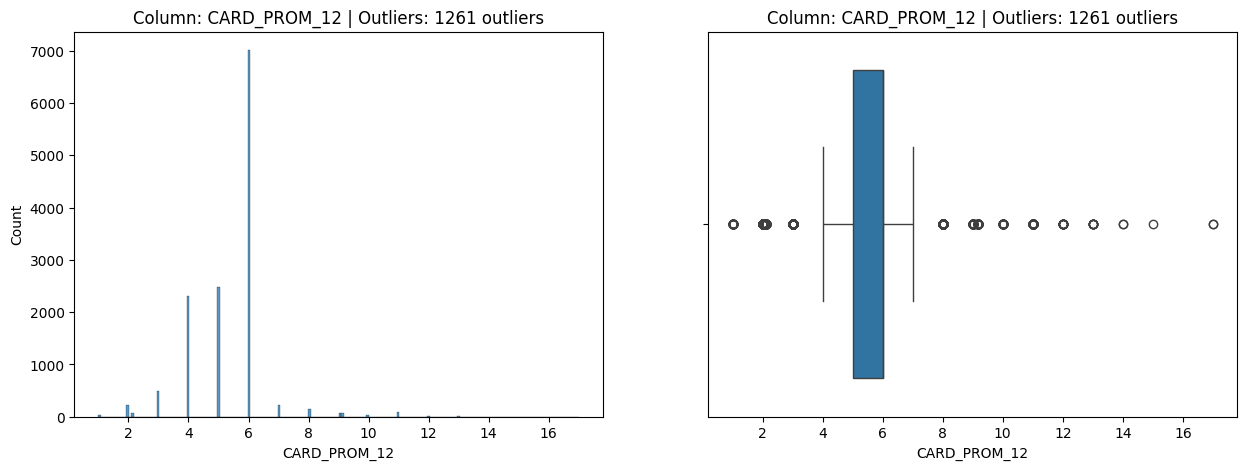

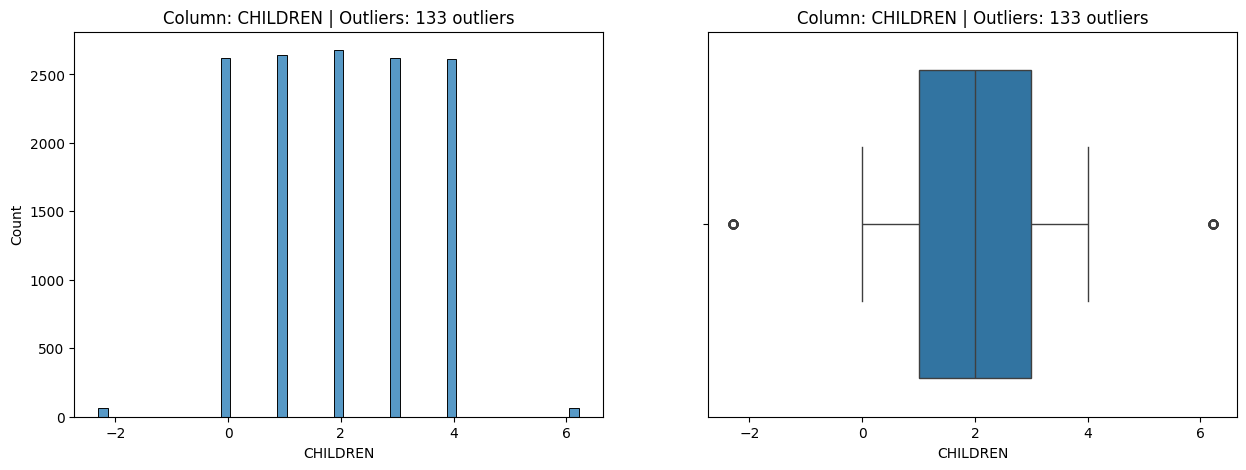

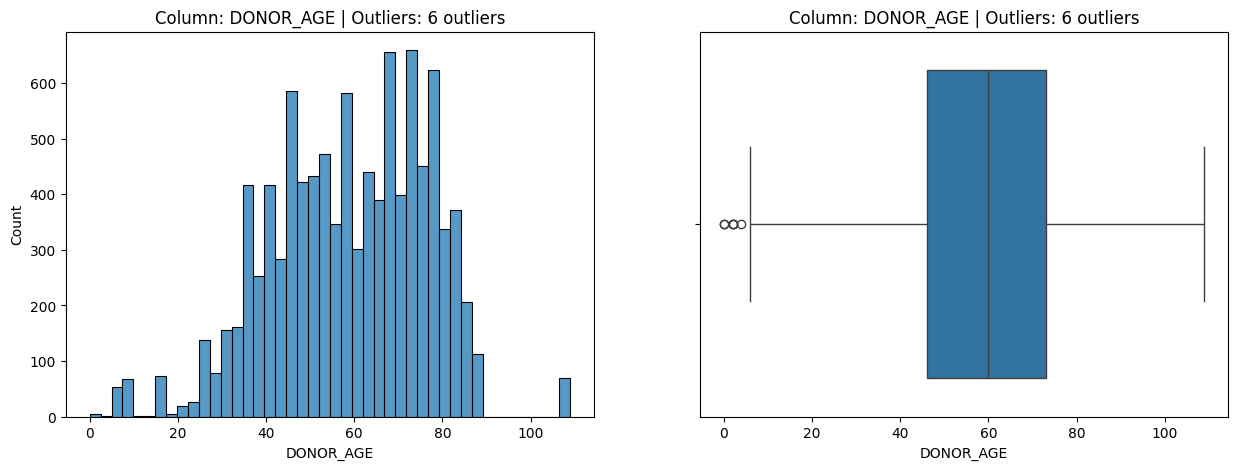

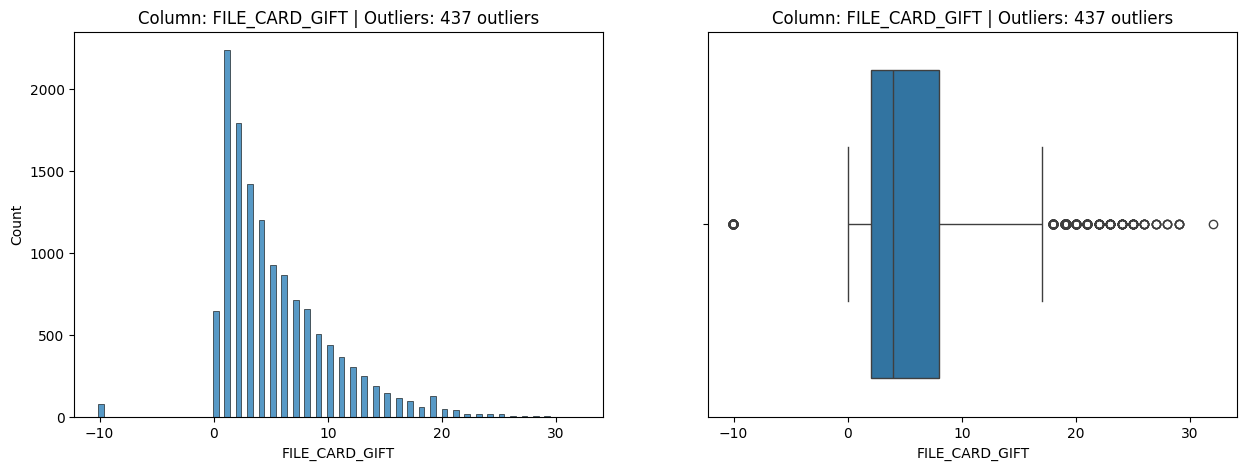

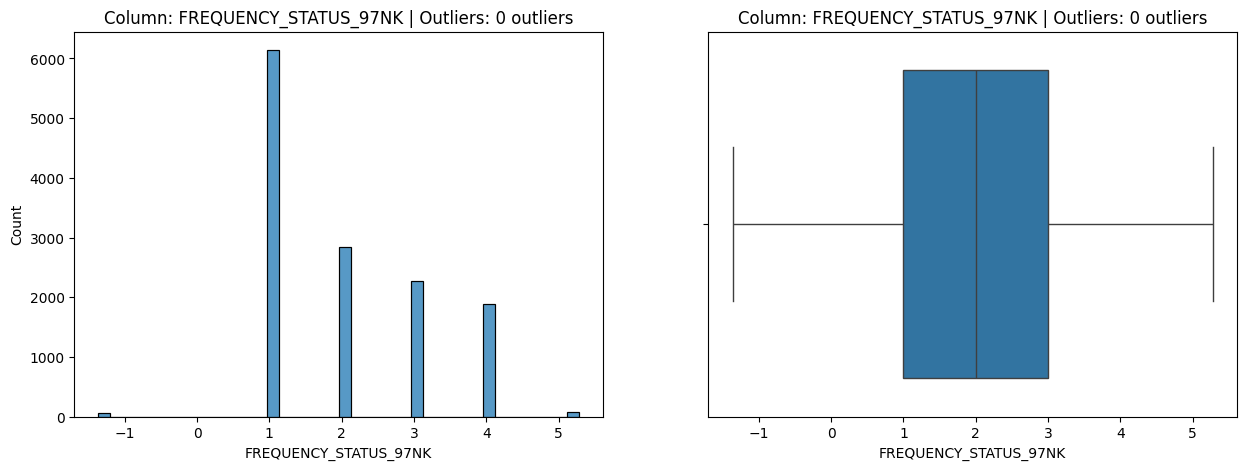

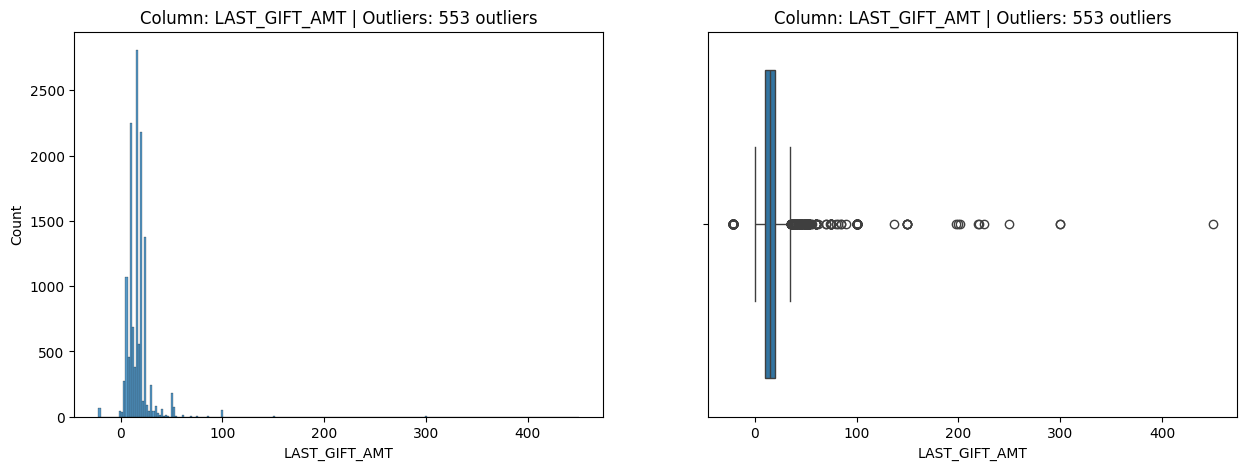

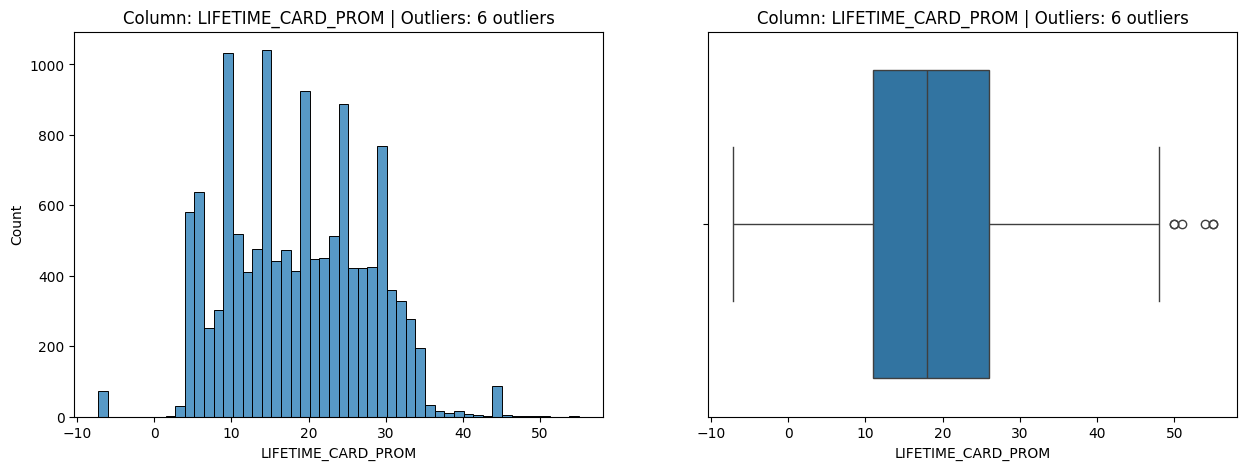

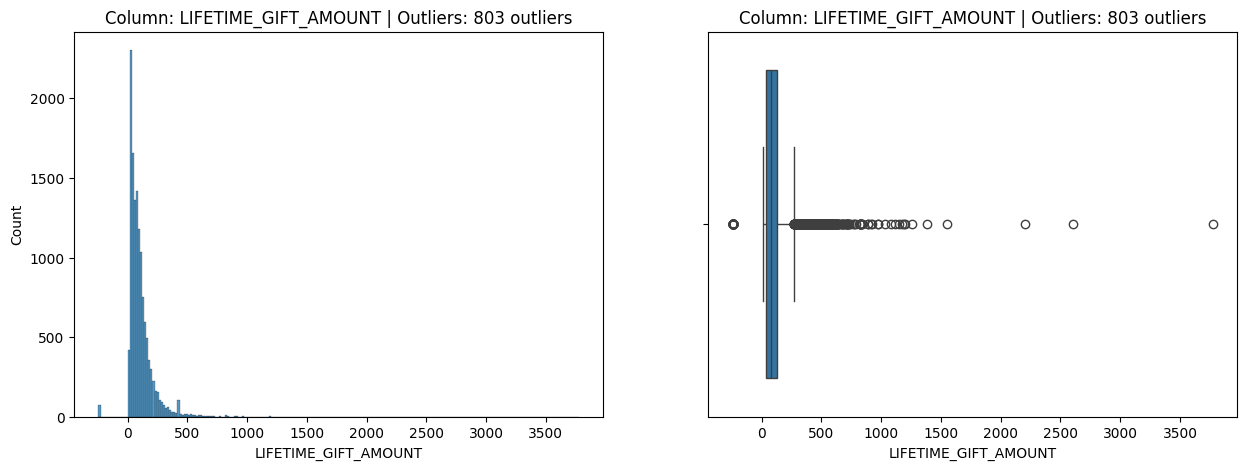

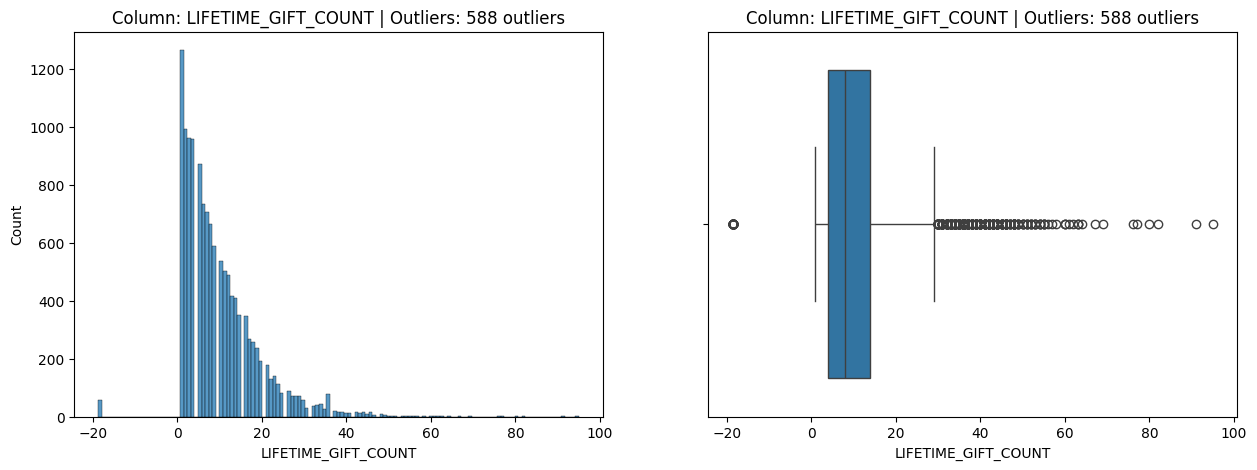

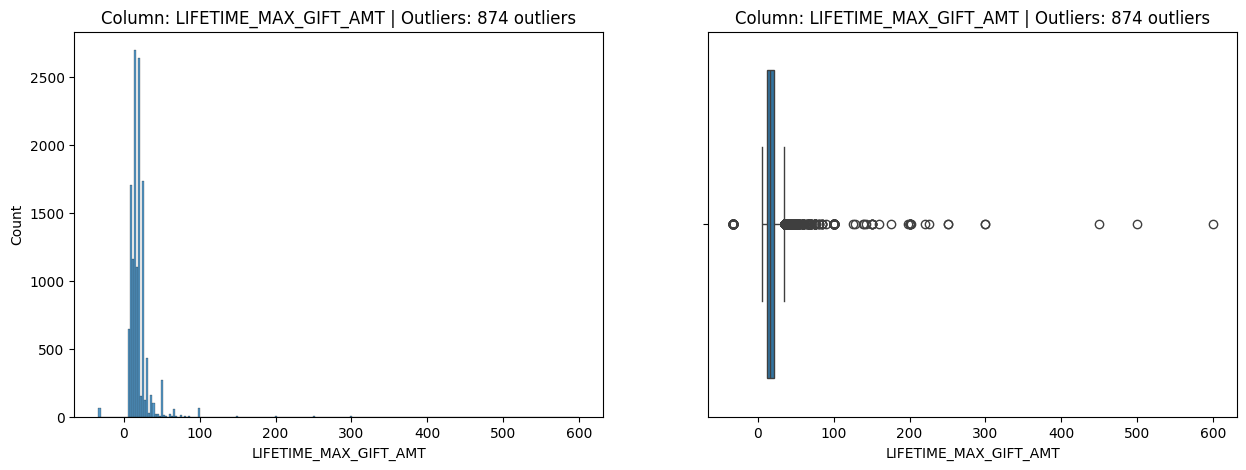

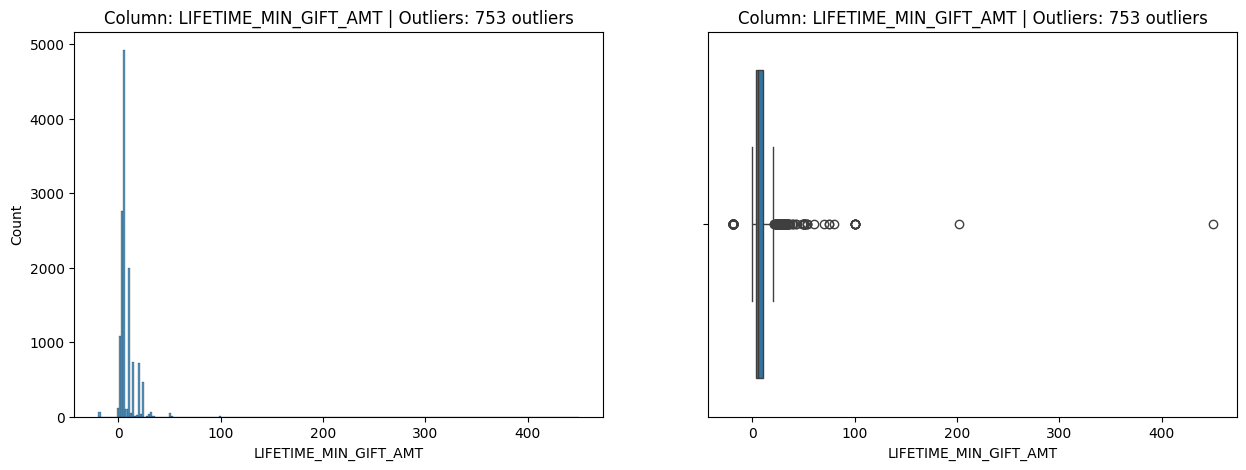

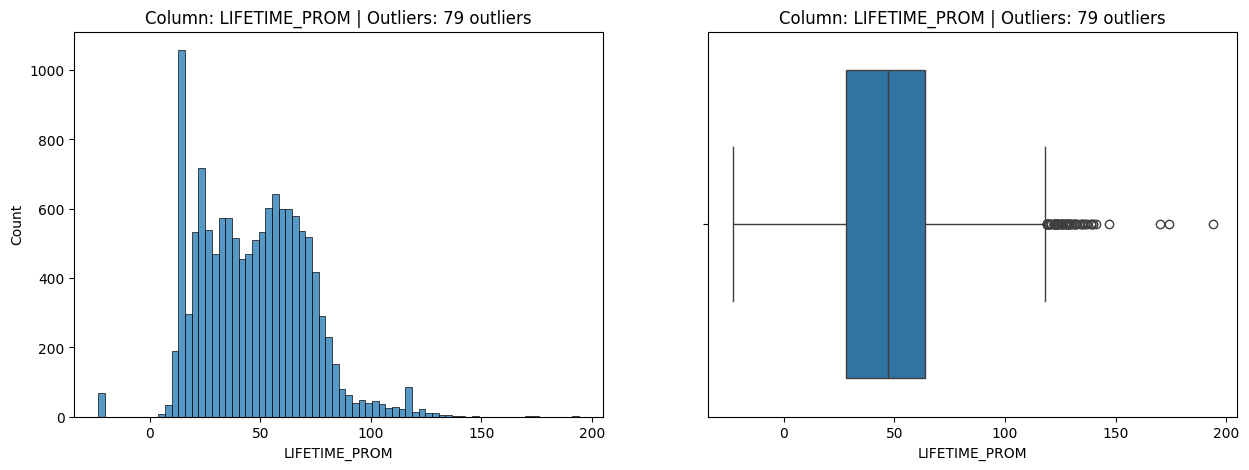

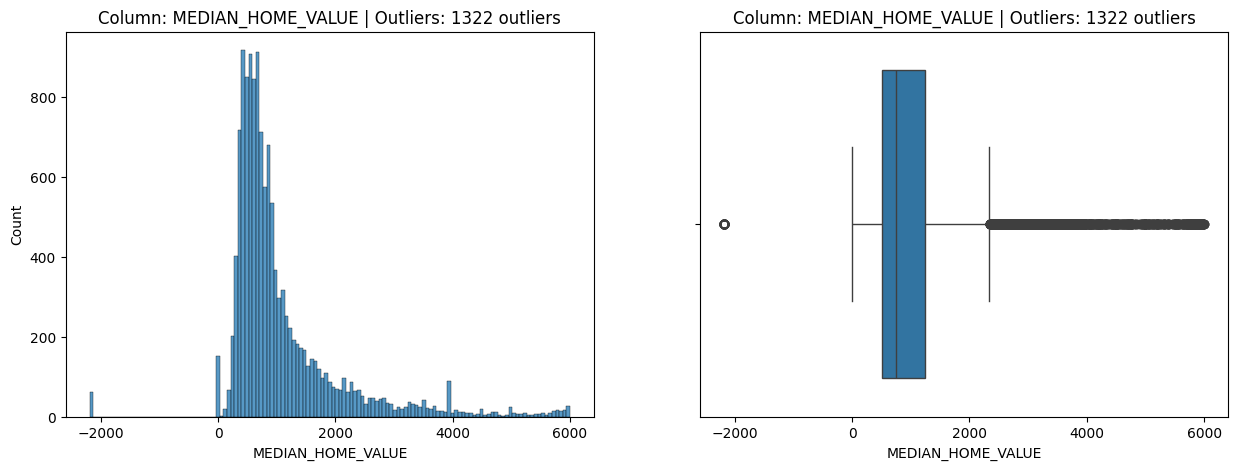

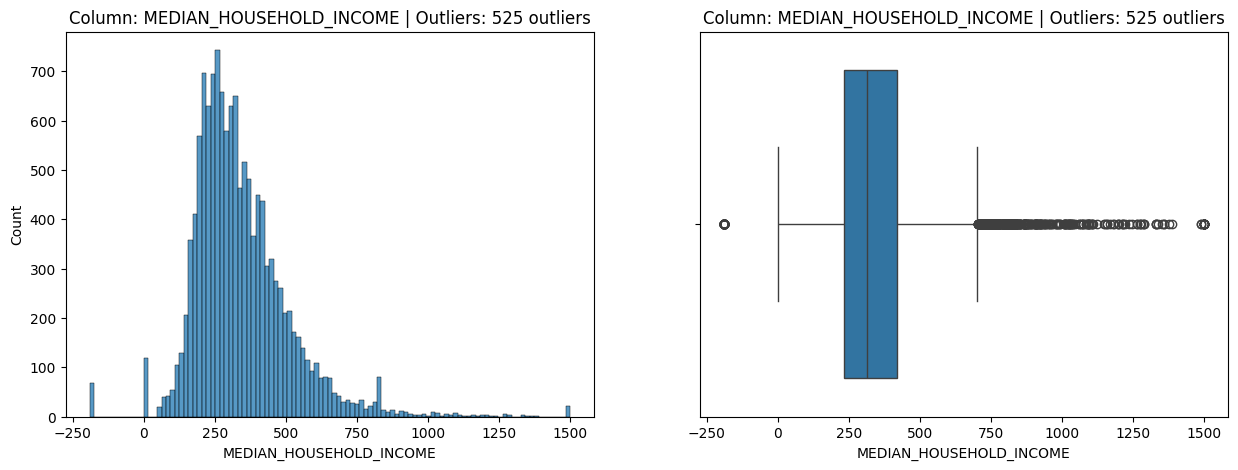

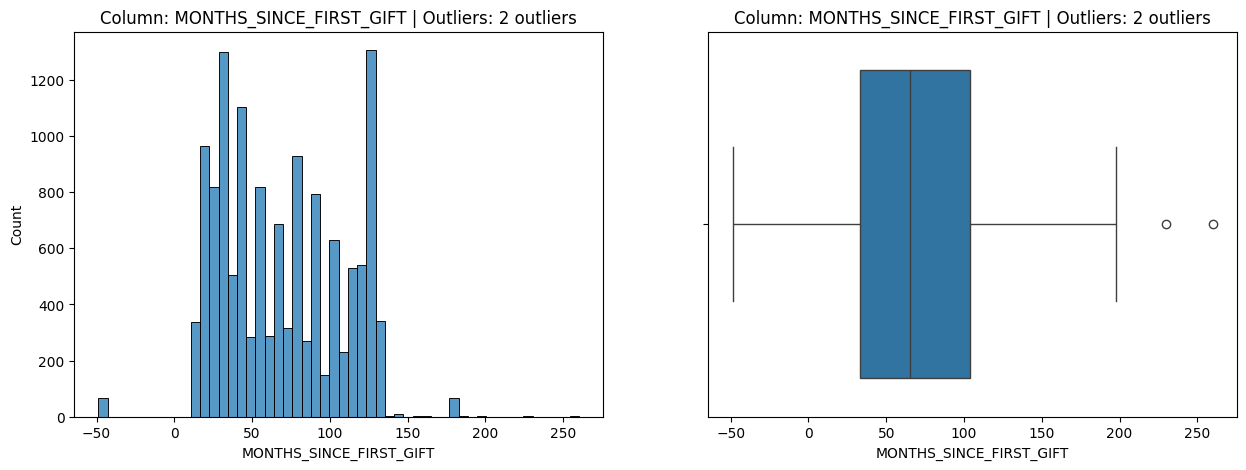

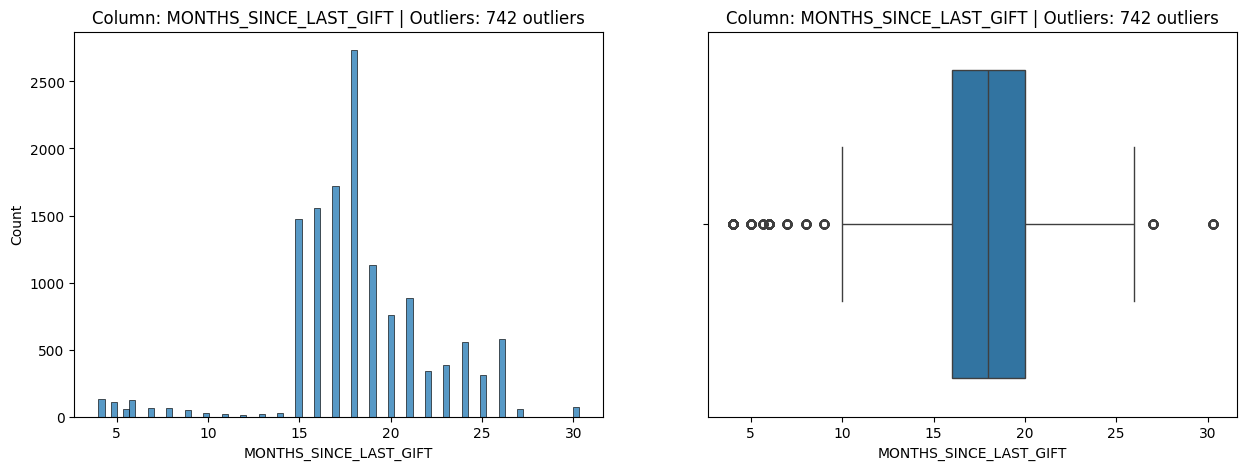

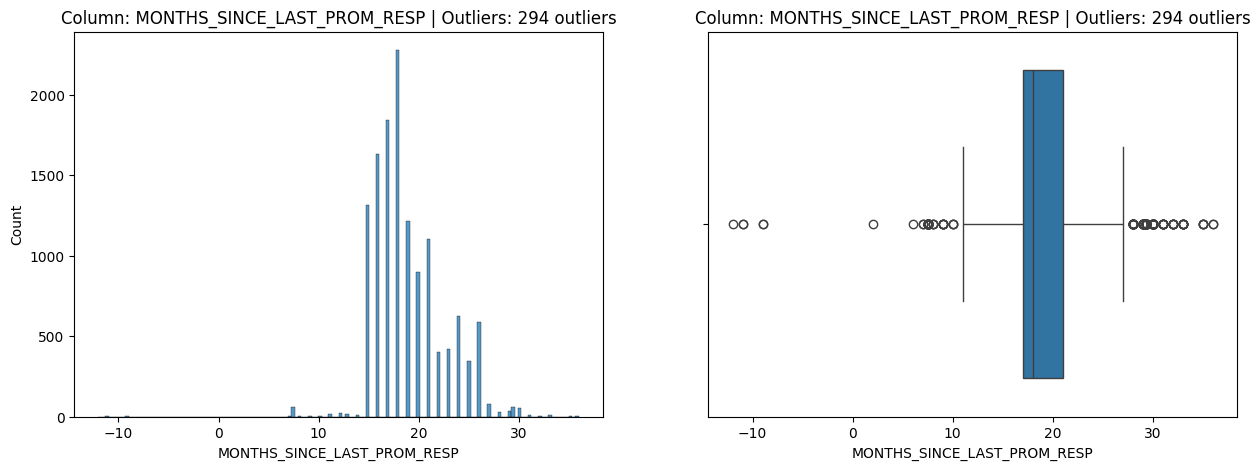

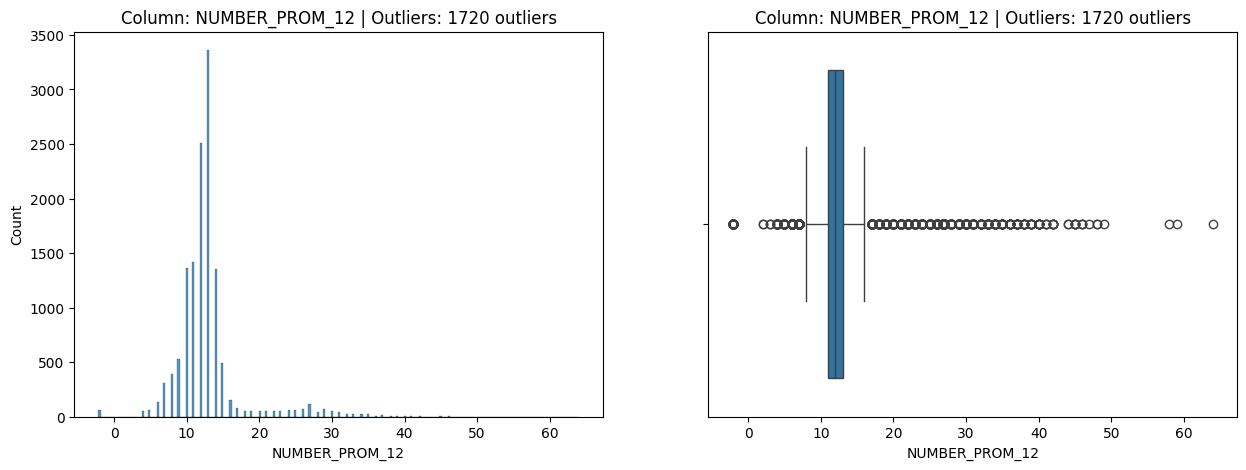

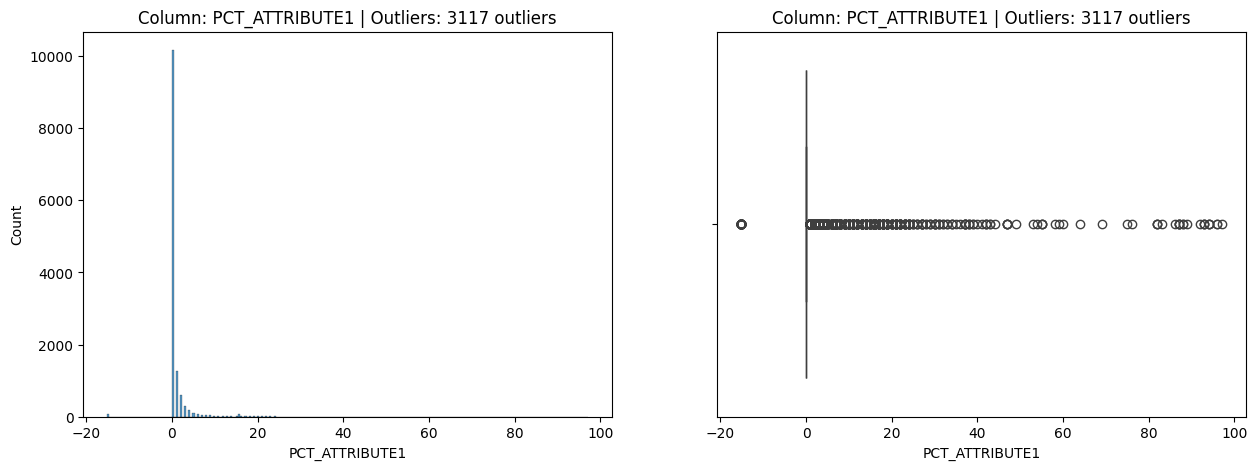

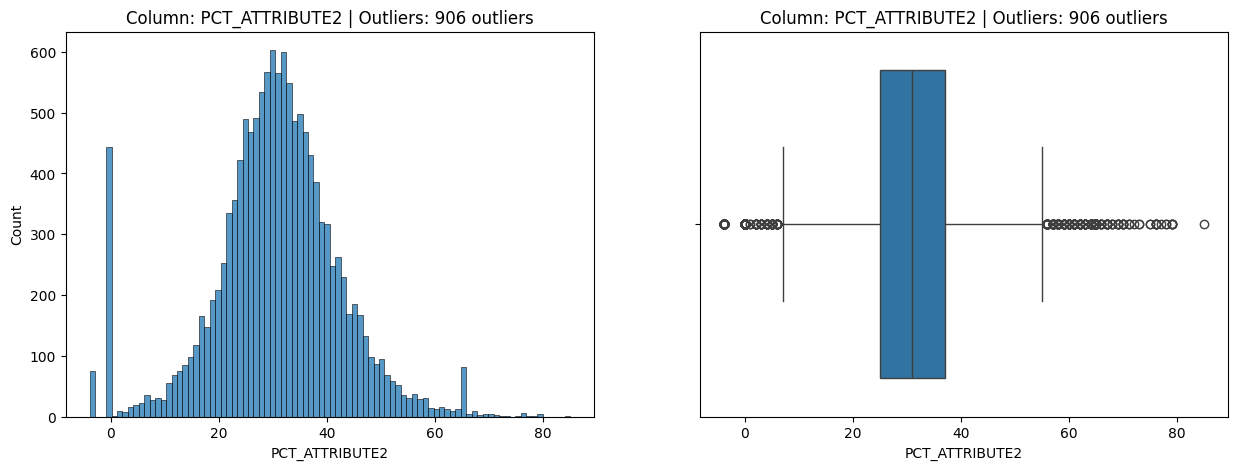

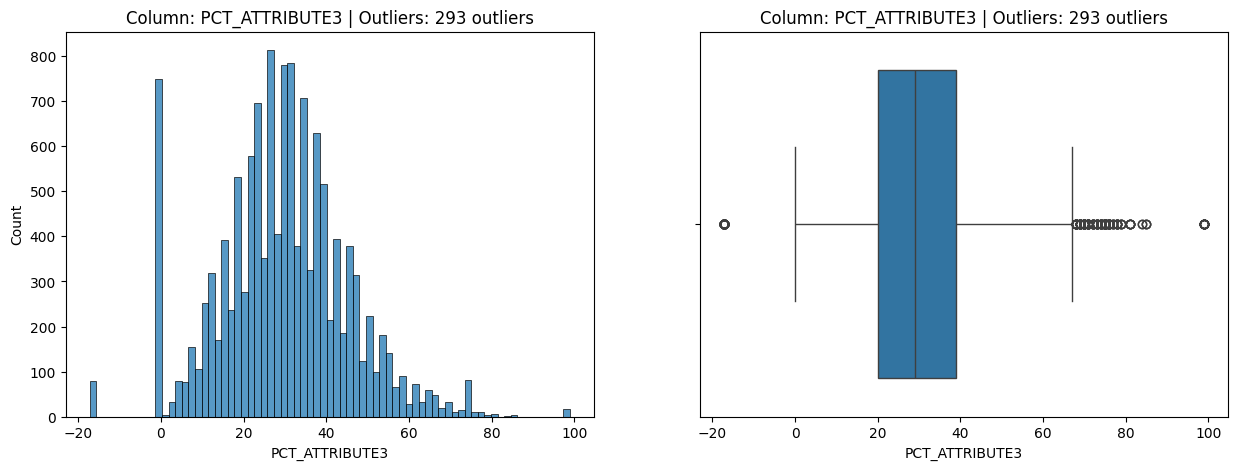

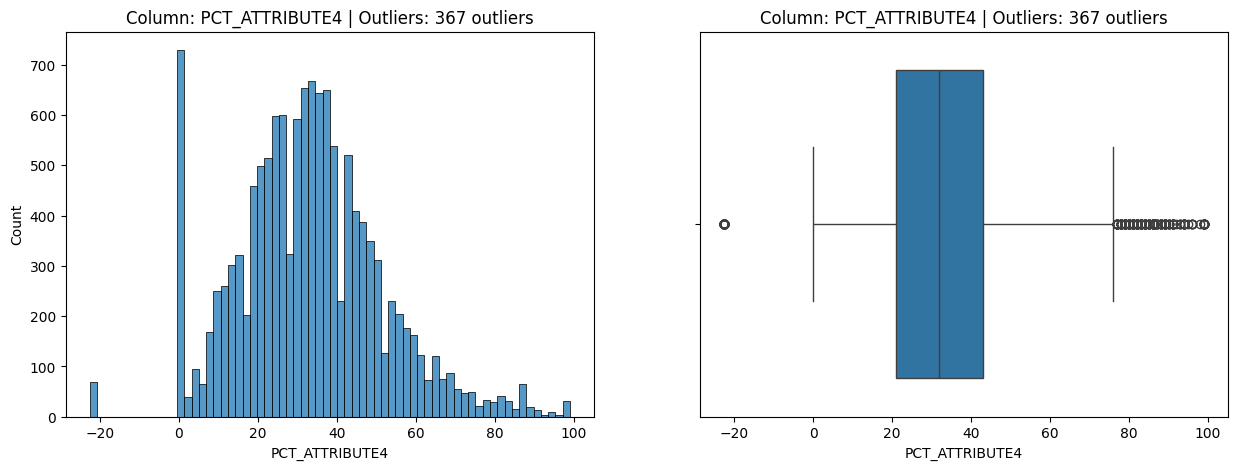

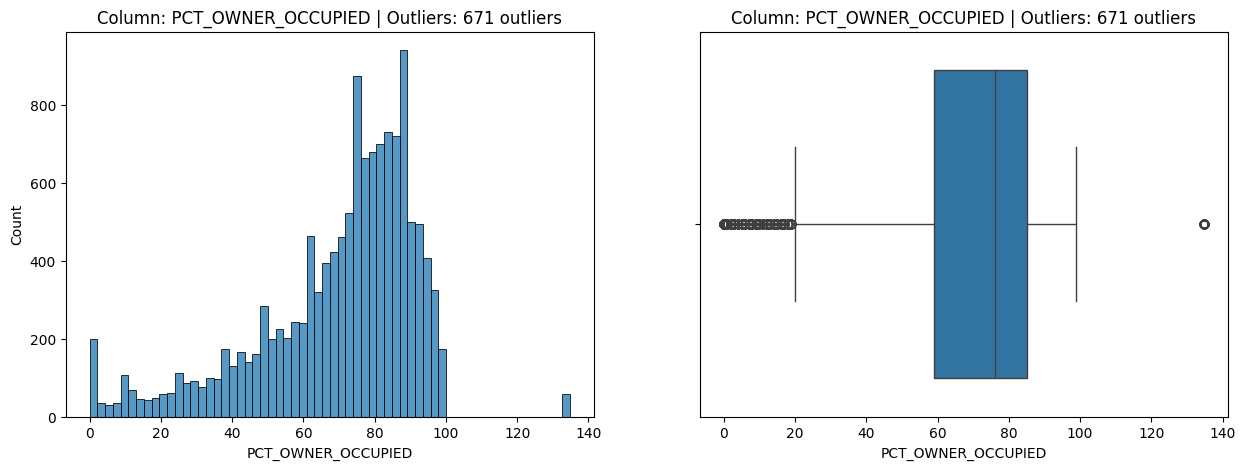

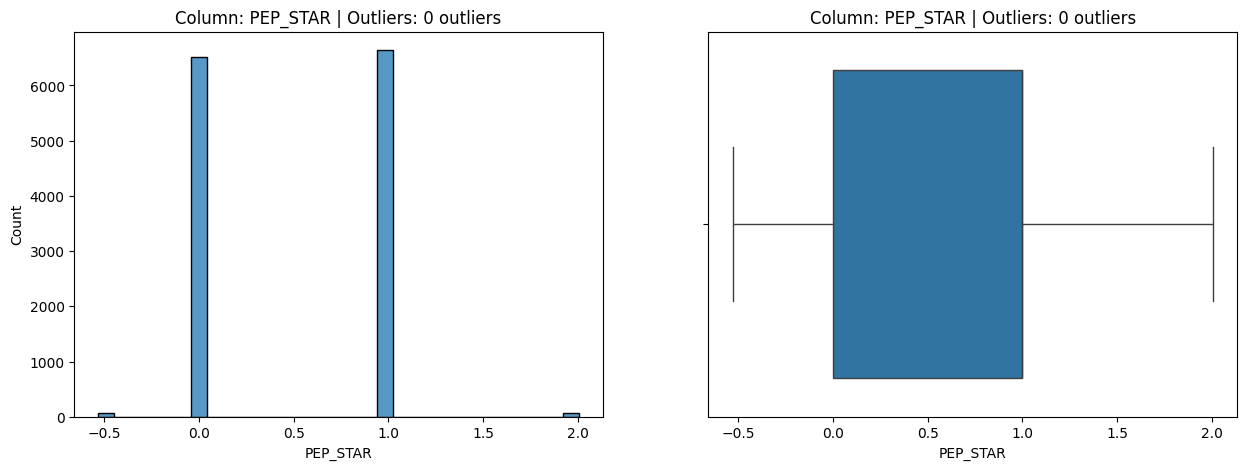

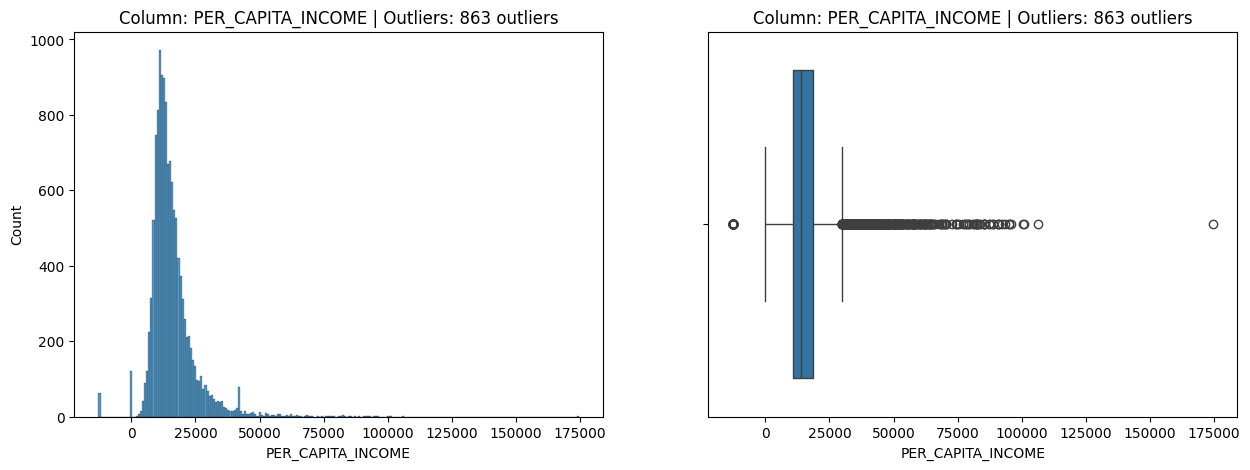

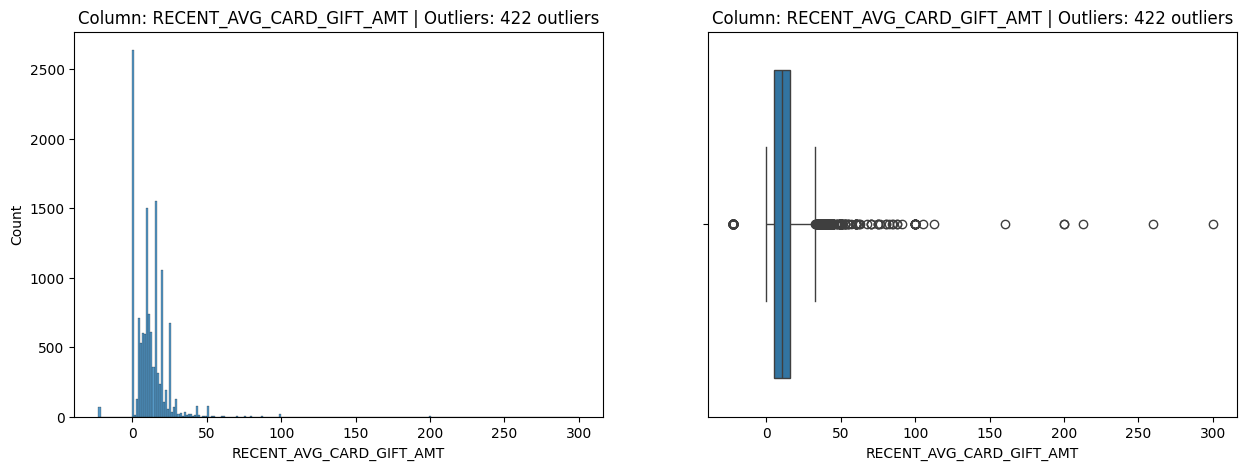

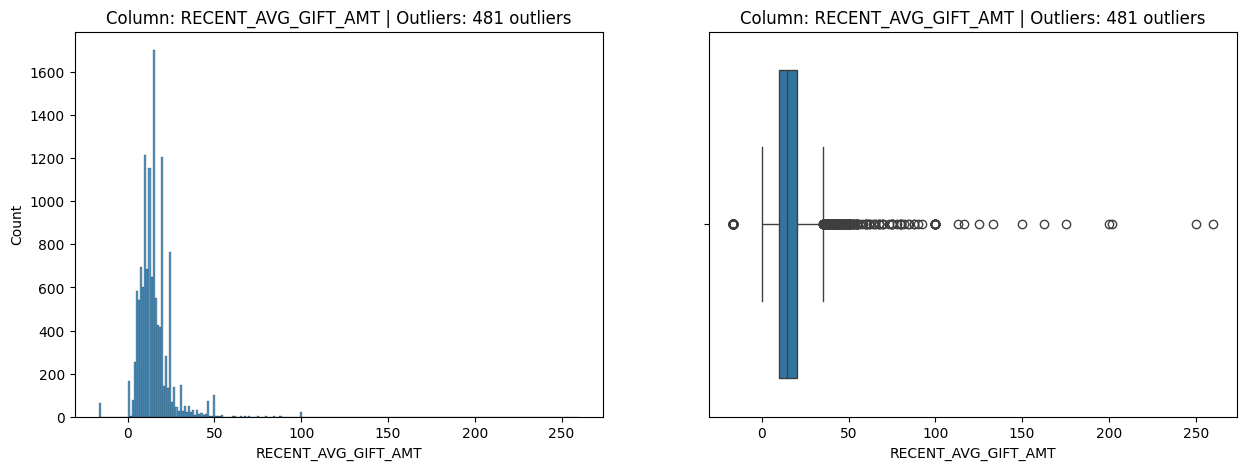

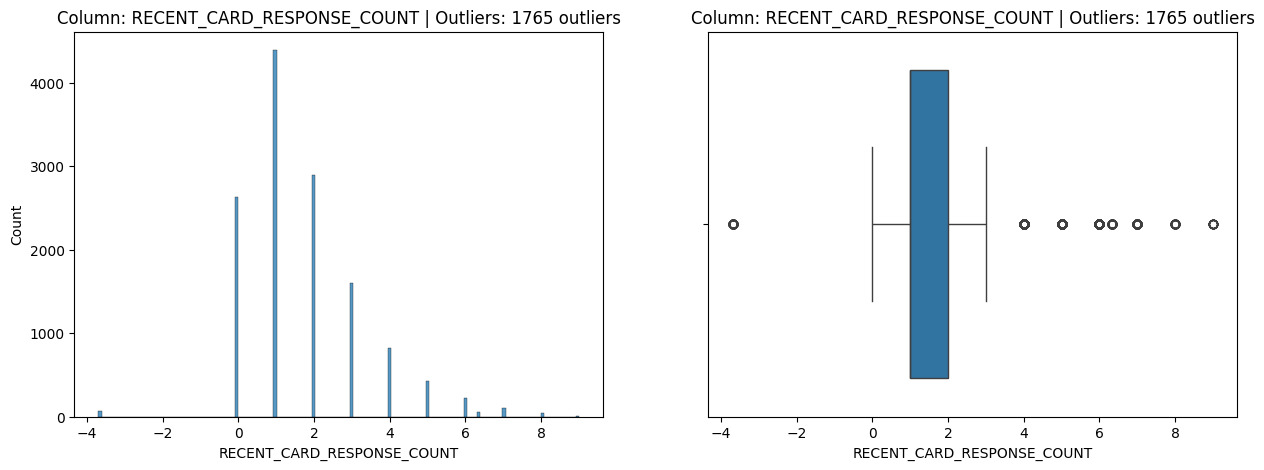

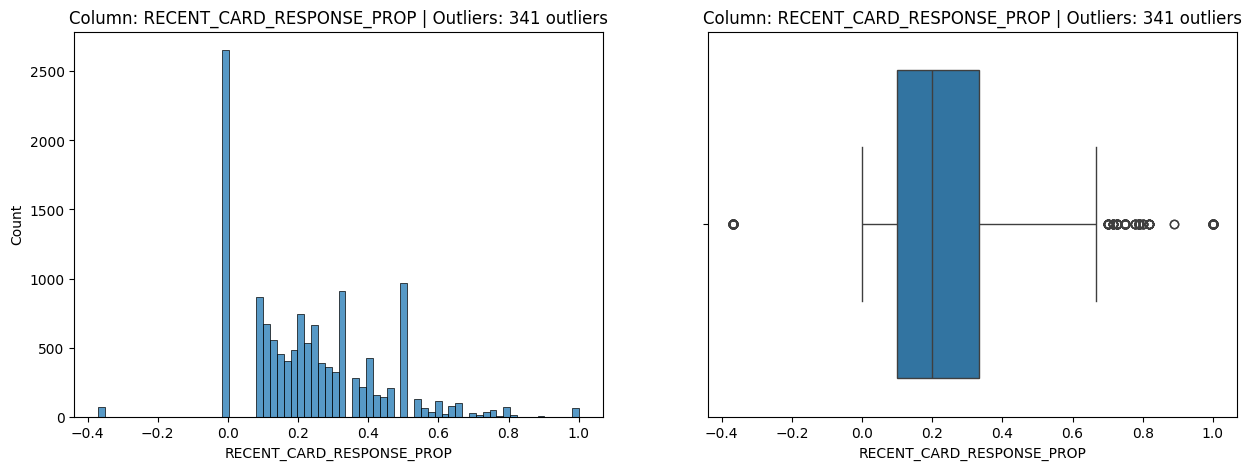

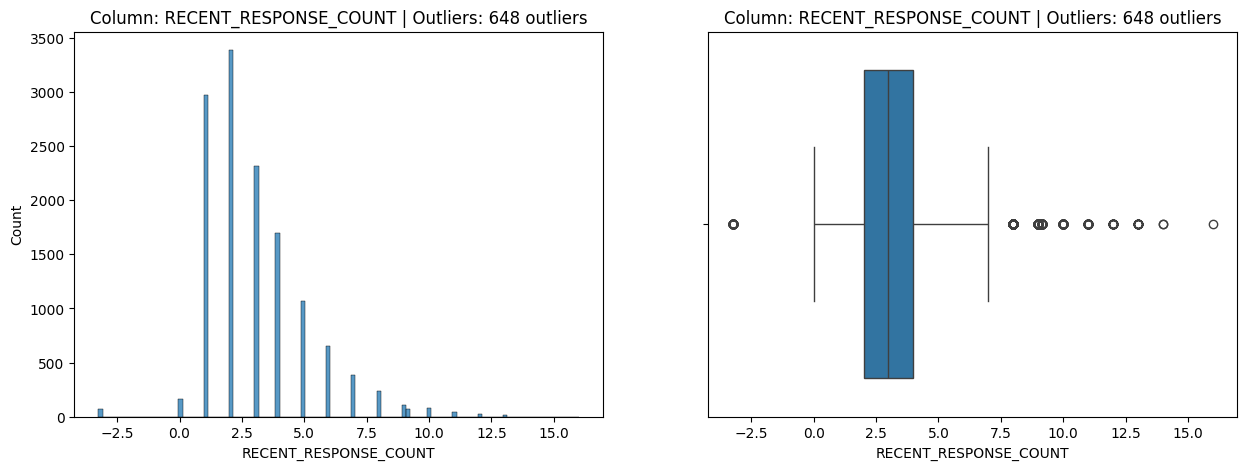

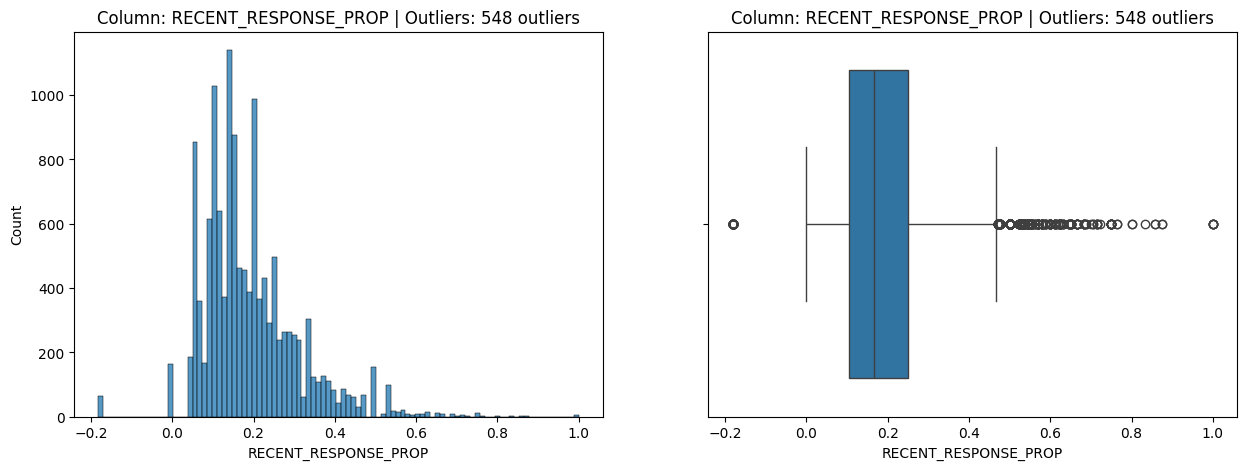

In [65]:
distribution_plot_grid(data, num_cols)

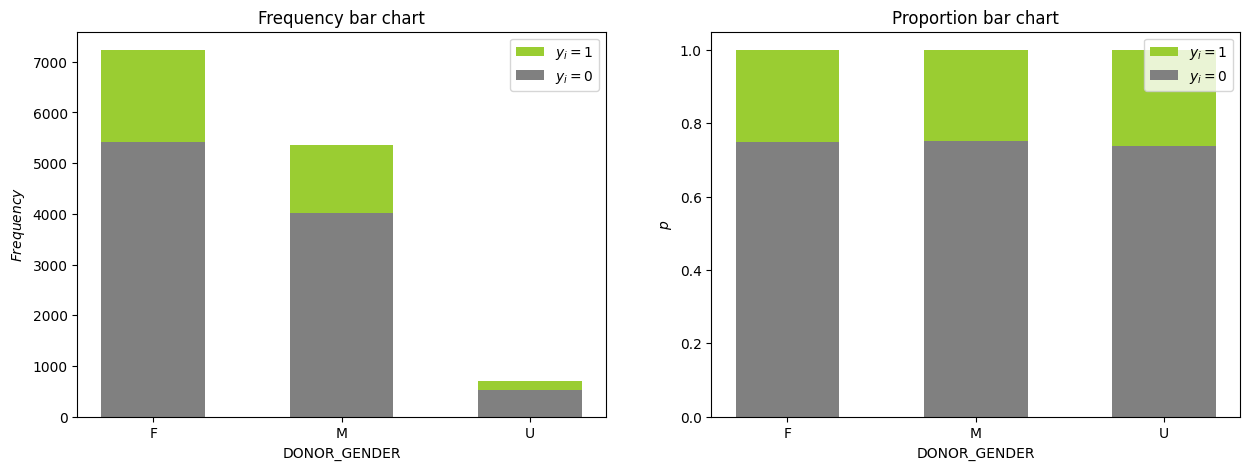

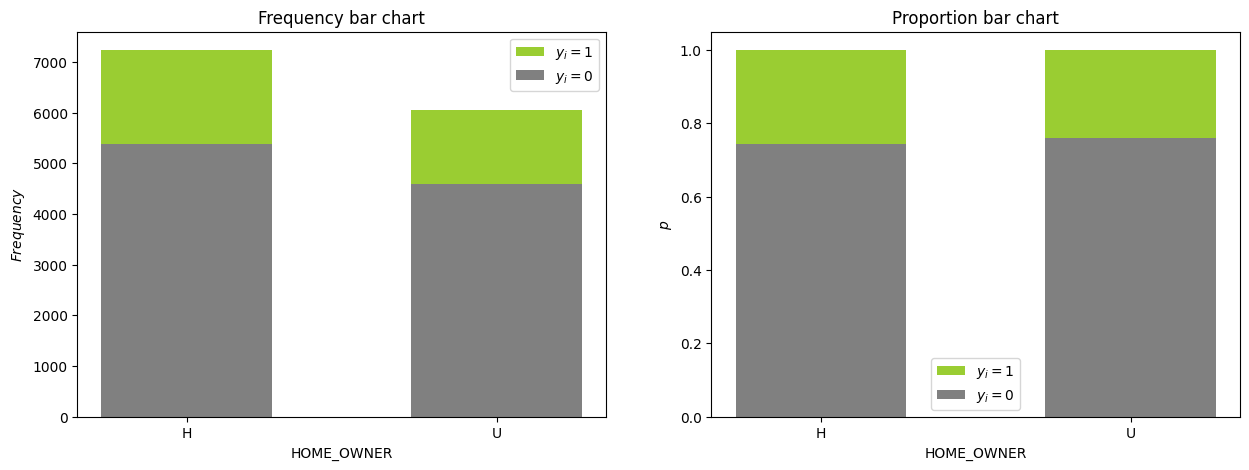

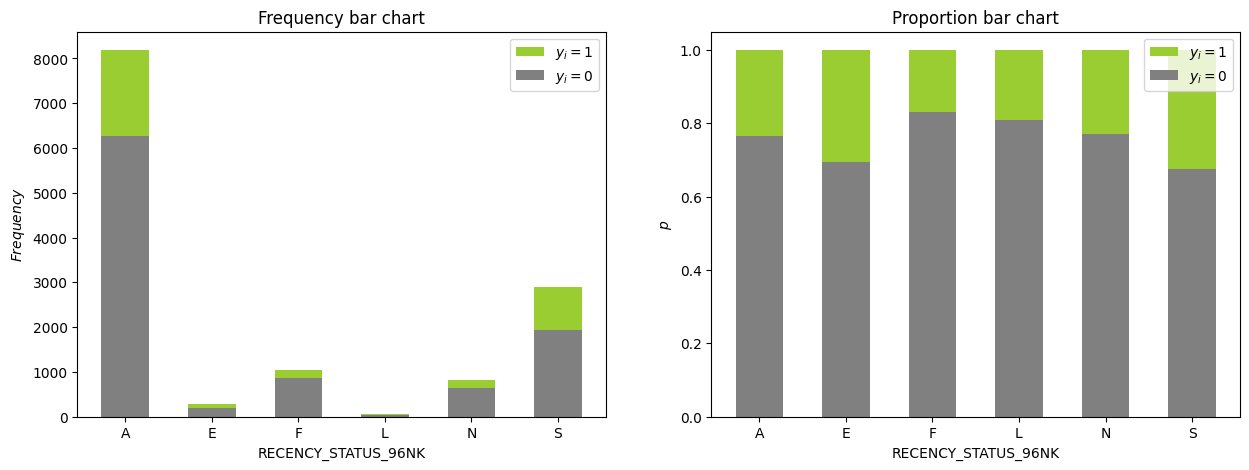

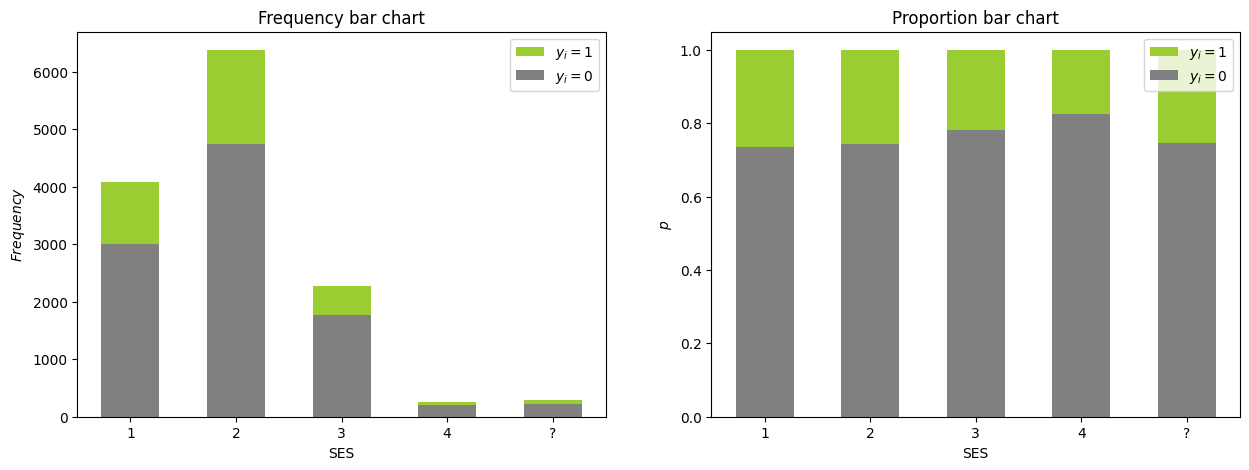

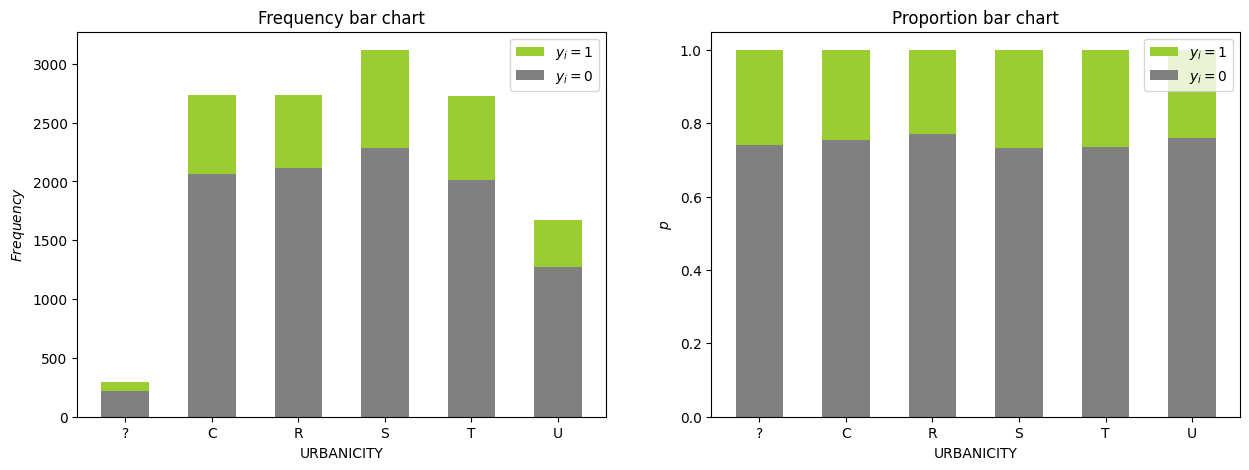

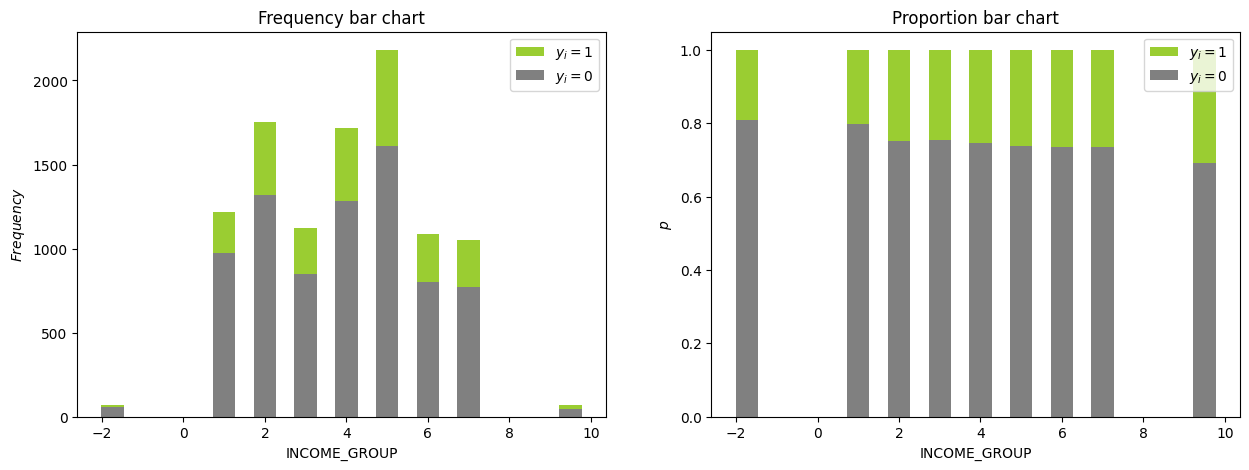

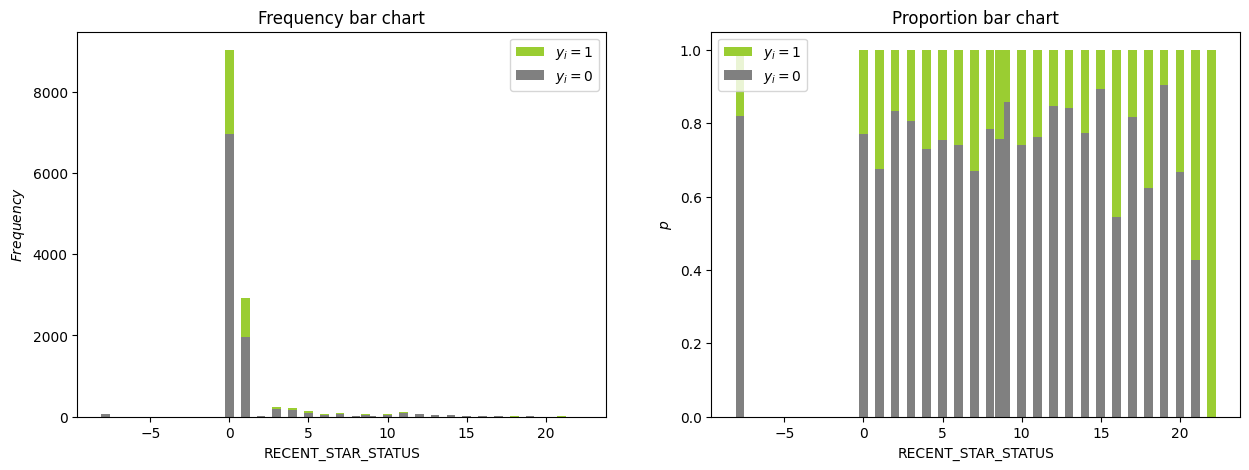

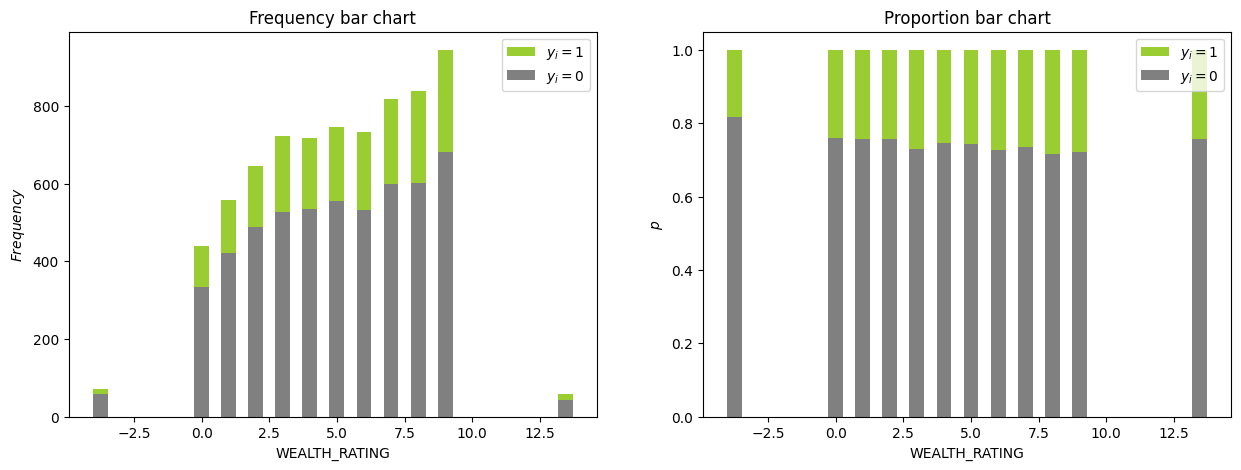

In [66]:
bar_charts_categorical(data, cat_cols, 'TARGET_B')

# Other/Extra

## Feature Selection?

In [67]:
data_no_nan = data.dropna()

In [68]:
chi2_TestIndependence(data, 'TARGET_B', cat_cols)

,Column,Suggestion
0,DONOR_GENDER,Discard Feature
1,HOME_OWNER,Keep Feature
2,RECENCY_STATUS_96NK,Keep Feature
3,SES,Keep Feature
4,URBANICITY,Keep Feature
5,INCOME_GROUP,Keep Feature
6,RECENT_STAR_STATUS,Keep Feature
7,WEALTH_RATING,Discard Feature


In [69]:
chi2_TestIndependence(data_no_nan, 'TARGET_B', cat_cols)

,Column,Suggestion
0,DONOR_GENDER,Discard Feature
1,HOME_OWNER,Discard Feature
2,RECENCY_STATUS_96NK,Keep Feature
3,SES,Keep Feature
4,URBANICITY,Discard Feature
5,INCOME_GROUP,Discard Feature
6,RECENT_STAR_STATUS,Discard Feature
7,WEALTH_RATING,Discard Feature


In [70]:
encoder = OrdinalEncoder()
encoded = encoder.fit_transform(data_no_nan[cat_cols])
encoded

array([[ 0.,  0.,  0., ...,  5.,  1.,  2.],
       [ 0.,  0.,  0., ...,  6.,  1.,  2.],
       [ 0.,  0.,  0., ...,  4.,  1.,  8.],
       ...,
       [ 1.,  1.,  5., ...,  2.,  2.,  7.],
       [ 1.,  0.,  0., ...,  6.,  1., 10.],
       [ 0.,  0.,  5., ...,  2.,  2.,  4.]], shape=(2345, 8))

In [71]:
anova = SelectKBest(f_classif, k='all')
X_anova = anova.fit_transform(encoded, data_no_nan['TARGET_B'])
selected_features = pd.Series(anova.get_support(), index = cat_cols)
selected_features

DONOR_GENDER           True
HOME_OWNER             True
RECENCY_STATUS_96NK    True
SES                    True
URBANICITY             True
INCOME_GROUP           True
RECENT_STAR_STATUS     True
WEALTH_RATING          True
dtype: bool

In [72]:
feature_scores = pd.Series(anova.pvalues_, index = cat_cols)
feature_scores

DONOR_GENDER          0.86
HOME_OWNER            0.23
RECENCY_STATUS_96NK   0.01
SES                   0.12
URBANICITY            0.42
INCOME_GROUP          0.05
RECENT_STAR_STATUS    0.68
WEALTH_RATING         0.26
dtype: float64

In [73]:
corr = data[num_cols].corr('spearman')

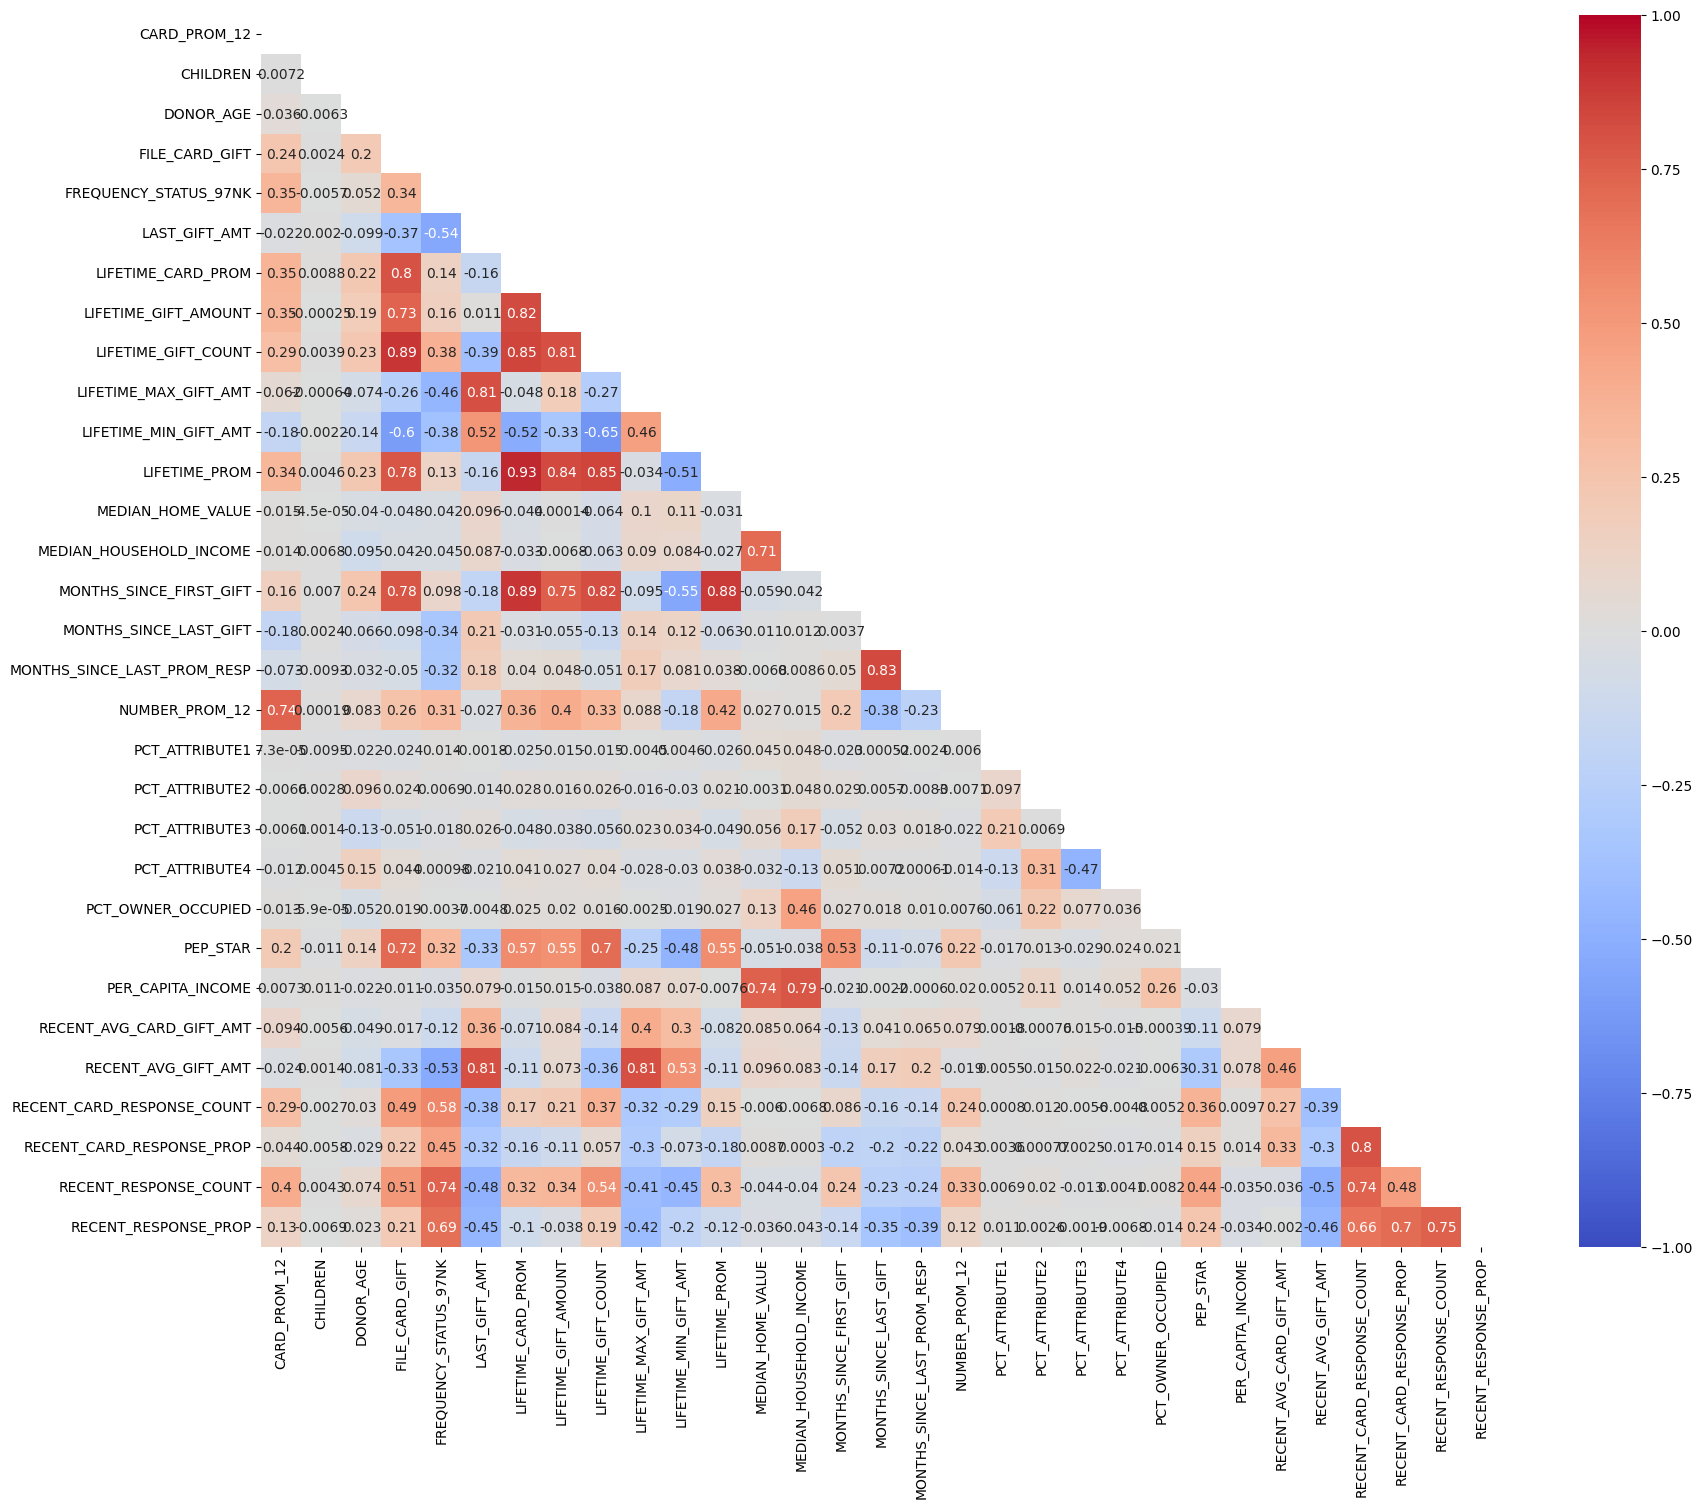

In [74]:
cor_heatmap(corr)